# Retrieval Component Analysis

Comparison of retrieval strategies for the HuggingFace documentation RAG system.

Sections:
1. Baseline retriever comparison (BM25, TF-IDF, Dense MiniLM)
2. Dense model benchmark (8 models: E5, BGE, GTE, Qwen)
3. Fine-tuning experiments (LoRA, Triplet Loss, FastText hybrid)
4. Hybrid retrieval strategies (RRF, Weighted, ColBERT-like)
5. Reranker uplift analysis
6. Final validation (E5-Large + BGE-Reranker-Large)

In [1]:
import json
import time
import hashlib
import os
import random
import warnings
from typing import List, Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import gc
from tqdm import tqdm
from tabulate import tabulate
from langchain_core.documents import Document
from sentence_transformers import SentenceTransformer, CrossEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
plt.rcParams["font.size"] = 10

GROUND_TRUTH_PATH = "ground_truth_qwery.json"
K_VALUES = [1, 2, 3, 5, 10]
METRIC_NAMES = ["hit_rate", "mrr", "f1", "precision", "recall", "accuracy"]
METRIC_LABELS = {
    "hit_rate": "Hit Rate",
    "mrr": "MRR",
    "f1": "F1-Score",
    "precision": "Precision",
    "recall": "Recall",
    "accuracy": "Accuracy",
}


In [2]:
def clear_gpu_memory() -> None:
    """Release GPU memory and run garbage collection."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    gc.collect()
    time.sleep(1)


def load_queries(filepath: str) -> List[Dict]:
    """Load ground-truth query/document pairs from JSON."""
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    print(f"Loaded {len(data)} queries from {filepath}")
    return data


def create_documents(queries_data: List[Dict]) -> List[Document]:
    """Extract unique ground-truth documents from query data."""
    docs, seen = [], set()
    for item in queries_data:
        gt = item["ground_truth_doc"]
        uid = f"{gt['metadata']['source']}::{gt['page_content'][:100]}"
        if uid not in seen:
            docs.append(Document(page_content=gt["page_content"], metadata=gt["metadata"]))
            seen.add(uid)
    print(f"Created {len(docs)} unique documents")
    return docs


def get_doc_id(doc) -> str:
    """Compute a stable identifier for a document."""
    return hashlib.md5(
        f"{doc.metadata.get('source', '')}::{doc.page_content[:300]}".encode()
    ).hexdigest()


def _ground_truth_id(item: Dict) -> str:
    gt = item["ground_truth_doc"]
    return get_doc_id(
        type("D", (), {"page_content": gt["page_content"], "metadata": gt["metadata"]})()
    )


def calculate_metrics(retrieved_docs, ground_truth_id: str, k: int) -> Dict[str, float]:
    """Compute retrieval metrics for a single query at cut-off k."""
    found, position = False, None
    for idx, doc in enumerate(retrieved_docs[:k]):
        if get_doc_id(doc) == ground_truth_id:
            found, position = True, idx
            break
    tp = int(found)
    precision = tp / k if k > 0 else 0.0
    recall = float(tp)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        "hit_rate": float(found),
        "mrr": 1.0 / (position + 1) if position is not None else 0.0,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "accuracy": tp / k if found else 0.0,
    }


def evaluate_retriever(
    retriever,
    queries_data: List[Dict],
    k_values: List[int],
    name: str,
    dense_model=None,
) -> Dict:
    """Evaluate a retriever across multiple k values.

    Supports three retriever call signatures:
      invoke(query, top_k=N)                        -> List[Document]
      invoke(query, top_k=N)                        -> Tuple[List[Document], scores]
      invoke(query, top_k=N, dense_model=model)     -> List[Document]
    """
    bucket = {k: {m: [] for m in METRIC_NAMES} for k in k_values}

    for item in tqdm(queries_data, desc=name, ncols=70, leave=False):
        gt_id = _ground_truth_id(item)
        try:
            if dense_model is not None:
                result = retriever.invoke(item["query"], top_k=max(k_values), dense_model=dense_model)
            else:
                result = retriever.invoke(item["query"], top_k=max(k_values))
            retrieved = result[0] if isinstance(result, tuple) else result
        except Exception:
            retrieved = []

        for k in k_values:
            for m, v in calculate_metrics(retrieved, gt_id, k).items():
                bucket[k][m].append(v)

    aggregated = {}
    for k in k_values:
        aggregated[k] = {m: round(float(np.mean(bucket[k][m])), 4) for m in METRIC_NAMES}
        aggregated[k]["found_count"] = int(sum(bucket[k]["hit_rate"]))
    return aggregated


def print_results_table(
    all_results: Dict,
    k_values: List[int],
    queries_count: int,
    title: str = "Results",
) -> None:
    """Print a formatted comparison table for the given k values."""
    print(f"\n{'='*110}")
    print(title)
    print(f"{'='*110}")
    for k in k_values:
        print(f"\nTop-{k}:")
        rows = []
        for name, res in all_results.items():
            r = res[k]
            rows.append([
                name,
                f"{r['hit_rate']:.4f}",
                f"{r['mrr']:.4f}",
                f"{r['f1']:.4f}",
                f"{r['precision']:.4f}",
                f"{r['recall']:.4f}",
                f"{r['accuracy']:.4f}",
                f"{r['found_count']}/{queries_count}",
            ])
        print(tabulate(rows,
                       headers=["Model/Approach", "HR", "MRR", "F1", "Prec", "Rec", "Acc", "Found"],
                       tablefmt="grid"))


## 1. Baseline Retriever Comparison

BM25 (keyword-based), TF-IDF (sparse vector), and Dense (MiniLM) retrievers evaluated on the ground-truth dataset.

In [5]:
class BM25Retriever:
    """BM25 Okapi keyword retriever."""

    def __init__(self, documents: List[Document]):
        from rank_bm25 import BM25Okapi
        self.documents = documents
        tokenized = [doc.page_content.lower().split() for doc in documents]
        self.bm25 = BM25Okapi(tokenized)

    def invoke(self, query: str, top_k: int = 10) -> List[Document]:
        scores = self.bm25.get_scores(query.lower().split())
        top_idx = scores.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx if scores[i] > 0]


class TFIDFRetriever:
    """Sparse TF-IDF retriever."""

    def __init__(self, documents: List[Document]):
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.metrics.pairwise import cosine_similarity
        self.documents = documents
        self.vectorizer = TfidfVectorizer(lowercase=True, max_features=5000, ngram_range=(1, 2))
        self.matrix = self.vectorizer.fit_transform([d.page_content for d in documents])
        self._cosine = cosine_similarity

    def invoke(self, query: str, top_k: int = 10) -> List[Document]:
        q_vec = self.vectorizer.transform([query])
        sims = self._cosine(q_vec, self.matrix).flatten()
        top_idx = sims.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx if sims[i] > 0]


class MiniLMDenseRetriever:
    """Dense retriever using sentence-transformers/all-MiniLM-L6-v2."""

    MODEL = "sentence-transformers/all-MiniLM-L6-v2"

    def __init__(self, documents: List[Document]):
        print(f"Loading {self.MODEL}...")
        self.model = SentenceTransformer(self.MODEL)
        self.documents = documents
        texts = [d.page_content for d in documents]
        self.embeddings = self.model.encode(texts, convert_to_numpy=True)

    def invoke(self, query: str, top_k: int = 10) -> List[Document]:
        q_emb = self.model.encode([query], convert_to_numpy=True)
        sims = np.dot(self.embeddings, q_emb.T).flatten()
        return [self.documents[i] for i in sims.argsort()[-top_k:][::-1]]


# Run baseline comparison
queries = load_queries(GROUND_TRUTH_PATH)
documents = create_documents(queries)

retrievers = {
    "BM25": BM25Retriever(documents),
    "TF-IDF": TFIDFRetriever(documents),
    "Dense (MiniLM)": MiniLMDenseRetriever(documents),
}

baseline_results = {}
for name, retriever in retrievers.items():
    baseline_results[name] = evaluate_retriever(retriever, queries, K_VALUES, name)
    r3 = baseline_results[name][3]
    print(f"{name}: HR@3={r3['hit_rate']:.3f}, MRR@3={r3['mrr']:.3f}, F1@3={r3['f1']:.3f}")

print_results_table(baseline_results, K_VALUES, len(queries), "Baseline Retriever Comparison")

with open("baseline_comparison.json", "w", encoding="utf-8") as f:
    json.dump({"results": baseline_results, "k_values": K_VALUES}, f, ensure_ascii=False, indent=2)
print("Saved: baseline_comparison.json")


Loaded 1276 queries from ground_truth_qwery.json
Created 425 unique documents
Loading sentence-transformers/all-MiniLM-L6-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BM25: HR@3=0.717, MRR@3=0.642, F1@3=0.358


TF-IDF: HR@3=0.682, MRR@3=0.592, F1@3=0.341


Dense (MiniLM): HR@3=0.701, MRR@3=0.618, F1@3=0.350

Baseline Retriever Comparison

Top-1:
+------------------+--------+--------+--------+--------+--------+--------+----------+
| Model/Approach   |     HR |    MRR |     F1 |   Prec |    Rec |    Acc | Found    |
+==================+========+========+========+========+========+========+==========+
| BM25             | 0.5815 | 0.5815 | 0.5815 | 0.5815 | 0.5815 | 0.5815 | 742/1276 |
+------------------+--------+--------+--------+--------+--------+--------+----------+
| TF-IDF           | 0.5172 | 0.5172 | 0.5172 | 0.5172 | 0.5172 | 0.5172 | 660/1276 |
+------------------+--------+--------+--------+--------+--------+--------+----------+
| Dense (MiniLM)   | 0.5525 | 0.5525 | 0.5525 | 0.5525 | 0.5525 | 0.5525 | 705/1276 |
+------------------+--------+--------+--------+--------+--------+--------+----------+

Top-2:
+------------------+--------+--------+--------+--------+--------+--------+----------+
| Model/Approach   |     HR |    MRR |   

## 2. Dense Model Benchmark

Comparison of 8 dense embedding models across the `large` and `base` tiers:
- **Large**: multilingual-E5-large, BGE-large-en-v1.5, GTE-large
- **Qwen**: gte-Qwen2-1.5B-instruct, gte-Qwen2-7B-instruct
- **Base**: multilingual-E5-base, BGE-base-en-v1.5, GTE-base

Loaded 1276 queries from ground_truth_qwery.json
Created 425 unique documents

Dense model comparison: 8 models, k=[1, 2, 3, 5, 10]

[1/8] E5-large
  Free VRAM: 14.47 GB
  Loading E5-large...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Ready: embeddings shape (425, 768)


  HR@3=0.763, MRR@3=0.679, F1@3=0.382

Dense Model Benchmark

Top-1:
+------------------+--------+--------+--------+--------+--------+--------+----------+
| Model/Approach   |     HR |    MRR |     F1 |   Prec |    Rec |    Acc | Found    |
+==================+========+========+========+========+========+========+==========+
| E5-large         | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 864/1276 |
+------------------+--------+--------+--------+--------+--------+--------+----------+
| BGE-large        | 0.652  | 0.652  | 0.652  | 0.652  | 0.652  | 0.652  | 832/1276 |
+------------------+--------+--------+--------+--------+--------+--------+----------+
| GTE-large        | 0.6309 | 0.6309 | 0.6309 | 0.6309 | 0.6309 | 0.6309 | 805/1276 |
+------------------+--------+--------+--------+--------+--------+--------+----------+
| Qwen-1.5B        | 0.2273 | 0.2273 | 0.2273 | 0.2273 | 0.2273 | 0.2273 | 290/1276 |
+------------------+--------+--------+--------+--------+--------+------

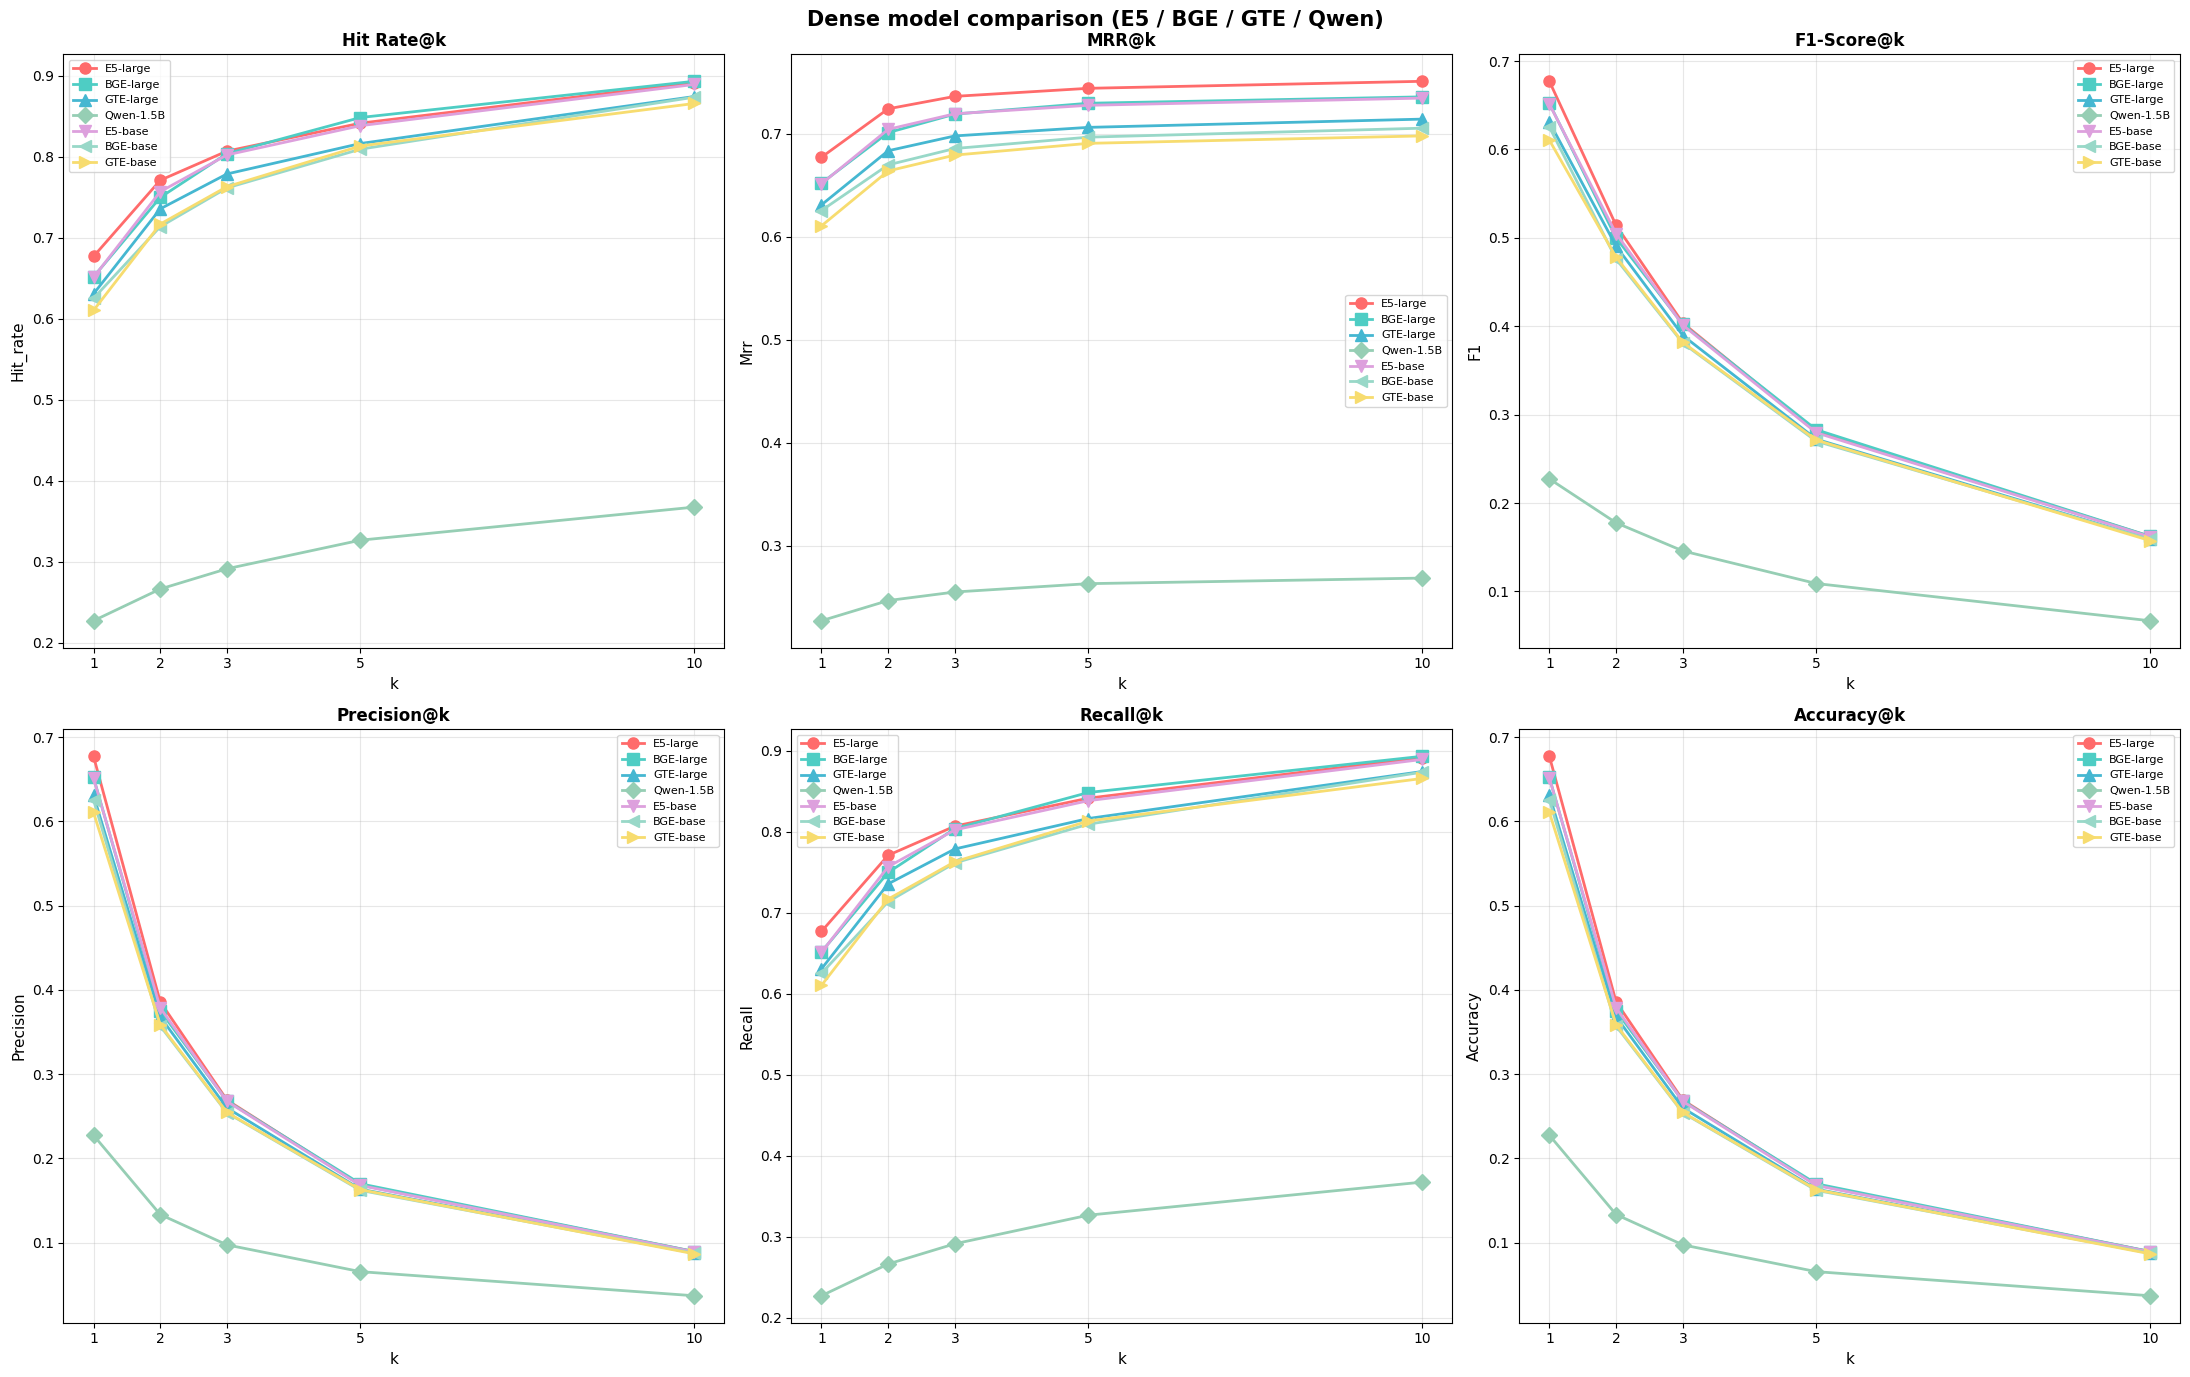

Saved: dense_models_comparison.png
Saved: dense_models_results.json

Best model by Hit Rate@3: E5-large (0.8072)


In [6]:
# ============================================================
# Multi-model dense retriever
# ============================================================

class MultiModelDenseRetriever:
    """Dense retriever that supports switching between named embedding models."""

    MODELS: Dict[str, str] = {
        "E5-large":   "intfloat/multilingual-e5-large",
        "BGE-large":  "BAAI/bge-large-en-v1.5",
        "GTE-large":  "thenlper/gte-large",
        "Qwen-1.5B":  "Alibaba-NLP/gte-Qwen2-1.5B-instruct",
        "Qwen-7B":    "Alibaba-NLP/gte-Qwen2-7B-instruct",
        "E5-base":    "intfloat/multilingual-e5-base",
        "BGE-base":   "BAAI/bge-base-en-v1.5",
        "GTE-base":   "thenlper/gte-base",
    }

    def __init__(self, documents: List[Document], model_name: str = "E5-large"):
        model_path = self.MODELS.get(model_name, model_name)
        if torch.cuda.is_available():
            free_gb = (
                torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated(0)
            ) / 1024**3
            print(f"  Free VRAM: {free_gb:.2f} GB")
            if model_name in ("Qwen-7B", "Qwen-1.5B") and free_gb < 6.0:
                print(f"  Warning: {model_name} requires 6+ GB VRAM.")
        print(f"  Loading {model_name}...")
        self.model = SentenceTransformer(model_path, device="cuda")
        self.documents = documents
        self.embeddings = self.model.encode(
            [d.page_content for d in documents],
            convert_to_numpy=True,
            show_progress_bar=False,
            batch_size=8,
        )
        print(f"  Ready: embeddings shape {self.embeddings.shape}")

    def invoke(self, query: str, top_k: int = 10) -> List[Document]:
        q_emb = self.model.encode([query], convert_to_numpy=True)
        sims = np.dot(self.embeddings, q_emb.T).flatten()
        return [self.documents[i] for i in sims.argsort()[-top_k:][::-1]]


# ============================================================
# Run dense model comparison
# ============================================================

def compare_dense_models(queries_data: List[Dict], documents: List[Document]) -> Dict:
    models = list(MultiModelDenseRetriever.MODELS.keys())
    all_results, failed = {}, []

    print(f"\nDense model comparison: {len(models)} models, k={K_VALUES}")
    print("=" * 100)

    for idx, model_name in enumerate(models):
        print(f"\n[{idx+1}/{len(models)}] {model_name}")
        if idx > 0:
            clear_gpu_memory()
        try:
            retriever = MultiModelDenseRetriever(documents, model_name)
            all_results[model_name] = evaluate_retriever(retriever, queries_data, K_VALUES, model_name)
            r3 = all_results[model_name][3]
            print(f"  HR@3={r3['hit_rate']:.3f}, MRR@3={r3['mrr']:.3f}, F1@3={r3['f1']:.3f}")
            del retriever
            clear_gpu_memory()
        except torch.cuda.OutOfMemoryError:
            print(f"  Skipped ({model_name}): CUDA out of memory")
            failed.append({"model": model_name, "reason": "OOM"})
            clear_gpu_memory()
        except Exception as e:
            print(f"  Skipped ({model_name}): {e}")
            failed.append({"model": model_name, "reason": str(e)})
            clear_gpu_memory()

    if not all_results:
        print("No models completed successfully.")
        return {}

    print_results_table(all_results, K_VALUES, len(queries_data), "Dense Model Benchmark")

    if failed:
        print("\nModels that could not be evaluated:")
        for f in failed:
            print(f"  {f['model']}: {f['reason']}")

    # Visualisation
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle("Dense model comparison (E5 / BGE / GTE / Qwen)", fontsize=15, fontweight="bold")
    colors = {
        "E5-large": "#FF6B6B", "BGE-large": "#4ECDC4", "GTE-large": "#45B7D1",
        "Qwen-1.5B": "#96CEB4", "Qwen-7B": "#FFEAA7",
        "E5-base": "#DDA0DD", "BGE-base": "#98D8C8", "GTE-base": "#F7DC6F",
    }
    markers = ["o", "s", "^", "D", "v", "<", ">", "P"]
    plot_metrics = list(zip(
        METRIC_NAMES,
        [METRIC_LABELS[m] + "@k" for m in METRIC_NAMES],
        axes.flatten(),
    ))
    for metric_key, title, ax in plot_metrics:
        for idx, (model_name, res) in enumerate(all_results.items()):
            values = [res[k][metric_key] for k in K_VALUES]
            ax.plot(K_VALUES, values, marker=markers[idx], linewidth=2,
                    markersize=8, label=model_name, color=colors.get(model_name))
        ax.set_xlabel("k", fontsize=11)
        ax.set_ylabel(metric_key.capitalize(), fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xticks(K_VALUES)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("dense_models_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: dense_models_comparison.png")

    with open("dense_models_results.json", "w", encoding="utf-8") as f:
        json.dump({"results": all_results, "failed": failed}, f, ensure_ascii=False, indent=2)
    print("Saved: dense_models_results.json")

    best = max(all_results.items(), key=lambda x: x[1][3]["hit_rate"])
    print(f"\nBest model by Hit Rate@3: {best[0]} ({best[1][3]['hit_rate']:.4f})")
    return all_results


queries = load_queries(GROUND_TRUTH_PATH)
documents = create_documents(queries)
dense_results = compare_dense_models(queries, documents)


## 3. Fine-tuning Experiments

Three approaches to improve E5-Large retrieval quality:
- **LoRA** — parameter-efficient fine-tuning with MNRL loss
- **Triplet Loss** — standard contrastive fine-tuning
- **FastText hybrid** — concatenation of dense and FastText embeddings

/tmp/ipykernel_3276/1730743250.py:5: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers.losses import MultipleNegativesRankingLoss, TripletLoss


Loaded 1276 queries from ground_truth_qwery.json
Created 425 unique documents

Fine-tuning approach comparison

[1/4] E5-Large Baseline


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[2/4] E5-Large + LoRA
Dataset: 6380 training examples
Loading base model: intfloat/multilingual-e5-large


...

Training FastText skipgram (dim=100, epochs=10)...
FastText ready — vocabulary: 8052 words


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

FastText: 100%|████████████████████| 425/425 [00:01<00:00, 322.75it/s]


Hybrid embeddings ready: (425, 1124)



Fine-tuning Experiment Results

Top-1:
+---------------------+--------+--------+--------+--------+--------+--------+----------+
| Model/Approach      |     HR |    MRR |     F1 |   Prec |    Rec |    Acc | Found    |
+=====================+========+========+========+========+========+========+==========+
| E5-Large Baseline   | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 864/1276 |
+---------------------+--------+--------+--------+--------+--------+--------+----------+
| E5-Large + Triplet  | 0.5353 | 0.5353 | 0.5353 | 0.5353 | 0.5353 | 0.5353 | 683/1276 |
+---------------------+--------+--------+--------+--------+--------+--------+----------+
| E5-Large + FastText | 0.4969 | 0.4969 | 0.4969 | 0.4969 | 0.4969 | 0.4969 | 634/1276 |
+---------------------+--------+--------+--------+--------+--------+--------+----------+

Top-2:
+---------------------+--------+--------+--------+--------+--------+--------+----------+
| Model/Approach      |     HR |    MRR |     F1 |   Prec |   

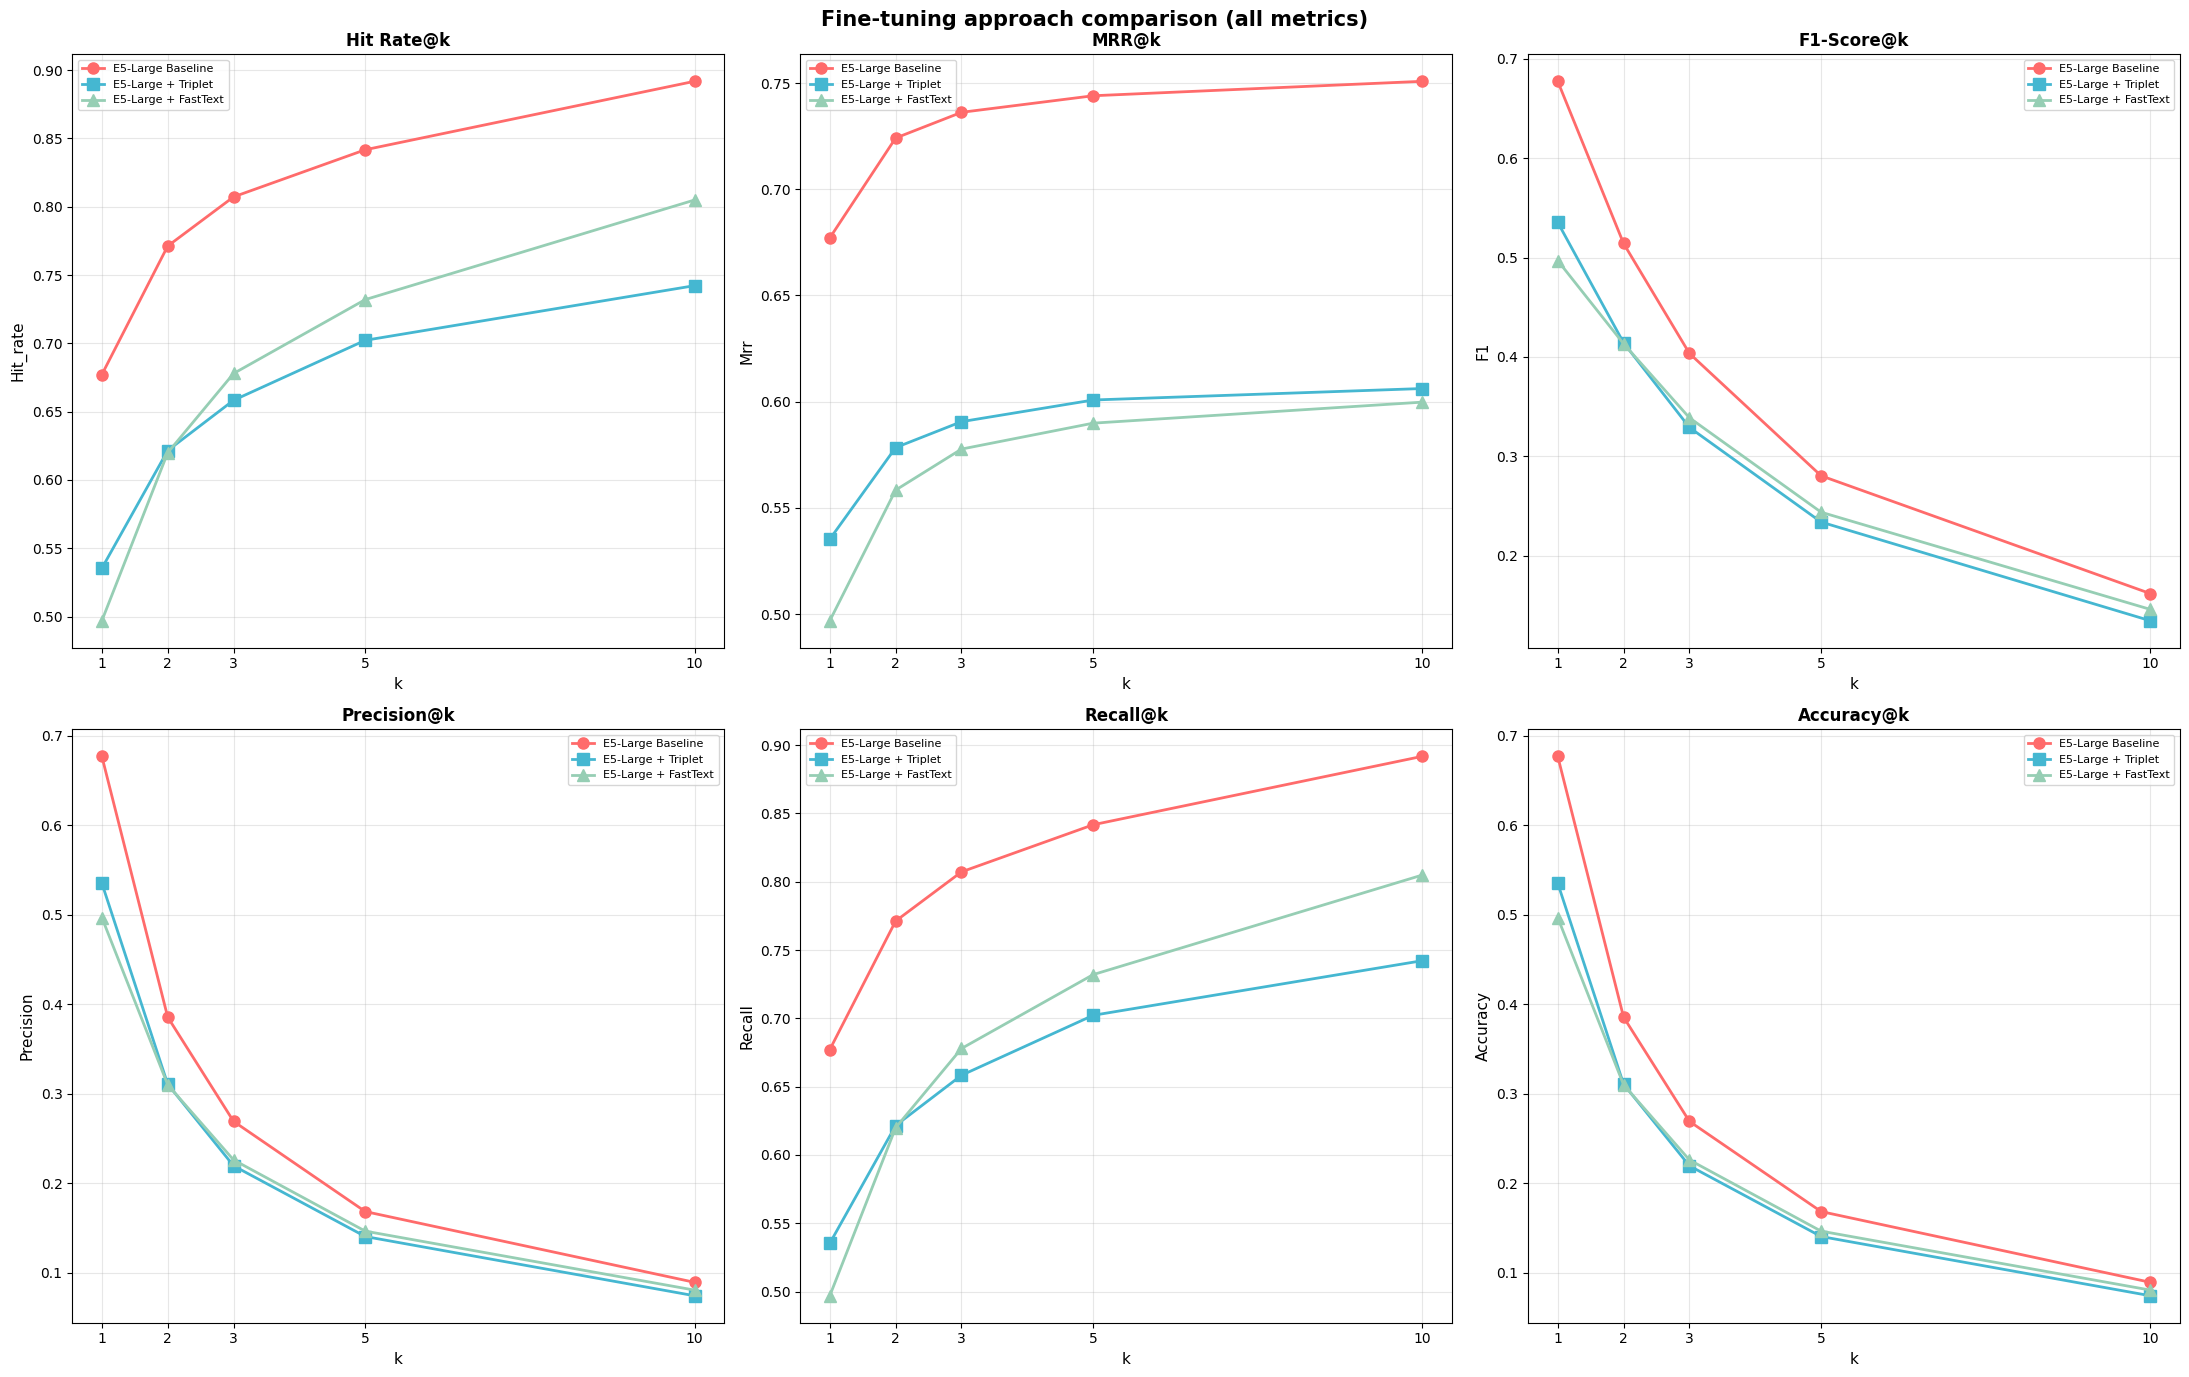

Saved: finetuning_comparison.png
Saved: finetuning_results.json


In [9]:
import tempfile
import fasttext
from datasets import Dataset
from sentence_transformers import SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.losses import MultipleNegativesRankingLoss, TripletLoss
from peft import LoraConfig, TaskType, get_peft_model
from sklearn.preprocessing import StandardScaler

# ============================================================
# FastText hybrid embedder
# ============================================================

class FastTextEmbedder:
    """Trains a FastText skipgram model on document texts."""

    def __init__(self, documents: List[Document], vector_size: int = 100, epochs: int = 10):
        self.vector_size = vector_size
        texts = [doc.page_content.lower().replace("\n", " ") for doc in documents]
        tmp = tempfile.NamedTemporaryFile(mode="w", delete=False, suffix=".txt", encoding="utf-8")
        for text in texts:
            clean = "".join(c if c.isalnum() or c.isspace() else " " for c in text)
            tmp.write(clean + "\n")
        tmp.close()
        print(f"Training FastText skipgram (dim={vector_size}, epochs={epochs})...")
        self.model = fasttext.train_unsupervised(
            tmp.name, model="skipgram", dim=vector_size,
            epoch=epochs, wordNgrams=2, minCount=1, thread=4,
        )
        os.unlink(tmp.name)
        print(f"FastText ready — vocabulary: {len(self.model.words)} words")

    def encode(self, text: str) -> np.ndarray:
        words = text.lower().split()
        if not words:
            return np.zeros(self.vector_size)
        vecs = [self.model.get_word_vector(w) for w in words]
        return np.mean(vecs, axis=0)


class FastTextHybridRetriever:
    """Concatenates E5-Large and FastText embeddings, then normalises."""

    def __init__(self, documents: List[Document],
                 dense_model_name: str = "intfloat/multilingual-e5-large",
                 fasttext_size: int = 100):
        self.documents = documents
        print("Loading dense model...")
        self.dense_model = SentenceTransformer(dense_model_name, device="cuda")
        self.ft = FastTextEmbedder(documents, vector_size=fasttext_size)
        texts = [d.page_content for d in documents]
        dense_embs = self.dense_model.encode(texts, convert_to_numpy=True, show_progress_bar=True)
        ft_embs = np.array([self.ft.encode(t) for t in tqdm(texts, desc="FastText", ncols=70)])
        hybrid = np.hstack([dense_embs, ft_embs])
        self.scaler = StandardScaler()
        self.embeddings = self.scaler.fit_transform(hybrid)
        print(f"Hybrid embeddings ready: {self.embeddings.shape}")

    def invoke(self, query: str, top_k: int = 10) -> List[Document]:
        q_dense = self.dense_model.encode([query], convert_to_numpy=True)
        q_ft = self.ft.encode(query).reshape(1, -1)
        q_hybrid = self.scaler.transform(np.hstack([q_dense, q_ft]))
        sims = np.dot(self.embeddings, q_hybrid.T).flatten()
        return [self.documents[i] for i in sims.argsort()[-top_k:][::-1]]

    def cleanup(self):
        del self.dense_model
        clear_gpu_memory()


# ============================================================
# LoRA fine-tuner
# ============================================================

class LoRAFinetuner:
    """Fine-tunes E5-Large with LoRA adapters using MNRL loss."""

    def __init__(self, base_model: str = "intfloat/multilingual-e5-large"):
        self.base_model = base_model
        self.trained_model = None

    def prepare_dataset(self, queries_data: List[Dict], augment: bool = True) -> Dataset:
        all_docs = [item["ground_truth_doc"]["page_content"] for item in queries_data]
        rows = []
        for item in queries_data:
            anchor = item["query"]
            positive = item["ground_truth_doc"]["page_content"]
            negatives = [d for d in all_docs if d != positive]
            for _ in range(min(3, len(negatives))):
                rows.append({"anchor": anchor, "positive": positive,
                             "negative": random.choice(negatives)})
            if augment and negatives:
                rows.append({"anchor": anchor + " please", "positive": positive,
                             "negative": random.choice(negatives)})
                rows.append({"anchor": "find: " + anchor, "positive": positive,
                             "negative": random.choice(negatives)})
        print(f"Dataset: {len(rows)} training examples")
        return Dataset.from_list(rows)

    def train(self, dataset: Dataset, output_dir: str = "./e5-lora-finetuned",
              epochs: int = 5, lr: float = 1e-5, lora_rank: int = 16):
        print(f"Loading base model: {self.base_model}")
        model = SentenceTransformer(self.base_model)
        peft_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            inference_mode=False,
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            lora_dropout=0.1,
            target_modules=["query", "key", "value"],
        )
        base = model[0].auto_model
        model[0].auto_model = get_peft_model(base, peft_config)
        model[0].auto_model.print_trainable_parameters()
        args = SentenceTransformerTrainingArguments(
            output_dir=output_dir,
            num_train_epochs=epochs,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=16,
            learning_rate=lr,
            warmup_ratio=0.1,
            fp16=True,
            gradient_checkpointing=True,
            eval_strategy="no",
            save_strategy="no",
            logging_steps=10,
            weight_decay=0.01,
        )
        trainer = SentenceTransformerTrainer(
            model=model, args=args,
            train_dataset=dataset, loss=MultipleNegativesRankingLoss(model),
        )
        print(f"Training LoRA (epochs={epochs}, lr={lr}, rank={lora_rank})...")
        trainer.train()
        model.save(output_dir)
        self.trained_model = SentenceTransformer(output_dir, device="cuda")
        print(f"Saved: {output_dir}")

    def get_retriever(self, documents: List[Document]):
        if self.trained_model is None:
            raise ValueError("Call train() first.")
        embs = self.trained_model.encode([d.page_content for d in documents], convert_to_numpy=True)

        class _Retriever:
            def __init__(self, model, docs, embs):
                self.model, self.documents, self.embeddings = model, docs, embs
            def invoke(self, query: str, top_k: int = 10) -> List[Document]:
                q = self.model.encode([query], convert_to_numpy=True)
                sims = np.dot(self.embeddings, q.T).flatten()
                return [self.documents[i] for i in sims.argsort()[-top_k:][::-1]]

        return _Retriever(self.trained_model, documents, embs)


# ============================================================
# Triplet-loss fine-tuner
# ============================================================

class TripletFinetuner:
    """Fine-tunes E5-Large with TripletLoss."""

    def __init__(self, base_model: str = "intfloat/multilingual-e5-large"):
        self.base_model = base_model
        self.trained_model = None

    def prepare_dataset(self, queries_data: List[Dict]) -> Dataset:
        all_docs = [item["ground_truth_doc"]["page_content"] for item in queries_data]
        rows = []
        for item in queries_data:
            anchor = item["query"]
            positive = item["ground_truth_doc"]["page_content"]
            negatives = [d for d in all_docs if d != positive]
            for neg in random.sample(negatives, min(2, len(negatives))):
                rows.append({"anchor": anchor, "positive": positive, "negative": neg})
        print(f"Dataset: {len(rows)} triplets")
        return Dataset.from_list(rows)

    def train(self, dataset: Dataset, output_dir: str = "./e5-triplet-finetuned", epochs: int = 3):
        print(f"Loading base model: {self.base_model}")
        model = SentenceTransformer(self.base_model)
        args = SentenceTransformerTrainingArguments(
            output_dir=output_dir,
            num_train_epochs=epochs,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=16,
            learning_rate=1e-5,
            warmup_ratio=0.1,
            fp16=True,
            gradient_checkpointing=True,
            eval_strategy="no",
            save_strategy="no",
            logging_steps=10,
        )
        trainer = SentenceTransformerTrainer(
            model=model, args=args,
            train_dataset=dataset, loss=TripletLoss(model),
        )
        print(f"Training Triplet Loss (epochs={epochs})...")
        trainer.train()
        model.save(output_dir)
        self.trained_model = SentenceTransformer(output_dir, device="cuda")
        print(f"Saved: {output_dir}")

    def get_retriever(self, documents: List[Document]):
        if self.trained_model is None:
            raise ValueError("Call train() first.")
        embs = self.trained_model.encode([d.page_content for d in documents], convert_to_numpy=True)

        class _Retriever:
            def __init__(self, model, docs, embs):
                self.model, self.documents, self.embeddings = model, docs, embs
            def invoke(self, query: str, top_k: int = 10) -> List[Document]:
                q = self.model.encode([query], convert_to_numpy=True)
                sims = np.dot(self.embeddings, q.T).flatten()
                return [self.documents[i] for i in sims.argsort()[-top_k:][::-1]]

        return _Retriever(self.trained_model, documents, embs)


# ============================================================
# Run fine-tuning comparison
# ============================================================

def compare_finetuning_approaches(queries_data: List[Dict], documents: List[Document]) -> Dict:
    all_results, failed = {}, []

    print("\nFine-tuning approach comparison")
    print("=" * 100)

    # 1. Baseline (no fine-tuning)
    print("\n[1/4] E5-Large Baseline")
    clear_gpu_memory()
    base_model = SentenceTransformer("intfloat/multilingual-e5-large", device="cuda")
    base_embs = base_model.encode([d.page_content for d in documents], convert_to_numpy=True)

    class _BaseRetriever:
        def __init__(self, model, docs, embs):
            self.model, self.documents, self.embeddings = model, docs, embs
        def invoke(self, query: str, top_k: int = 10) -> List[Document]:
            q = self.model.encode([query], convert_to_numpy=True)
            sims = np.dot(self.embeddings, q.T).flatten()
            return [self.documents[i] for i in sims.argsort()[-top_k:][::-1]]

    retriever = _BaseRetriever(base_model, documents, base_embs)
    all_results["E5-Large Baseline"] = evaluate_retriever(retriever, queries_data, K_VALUES, "Baseline")
    del base_model, base_embs, retriever

    # 2. LoRA
    print("\n[2/4] E5-Large + LoRA")
    try:
        clear_gpu_memory()
        lora = LoRAFinetuner()
        dataset = lora.prepare_dataset(queries_data)
        if len(dataset) > 0:
            lora.train(dataset, epochs=3)
            retriever = lora.get_retriever(documents)
            all_results["E5-Large + LoRA"] = evaluate_retriever(retriever, queries_data, K_VALUES, "LoRA")
            del lora, retriever
        else:
            raise ValueError("Empty training dataset")
    except Exception as e:
        print(f"  Failed: {e}")
        failed.append({"name": "E5-Large + LoRA", "error": str(e)})

    # 3. Triplet Loss
    print("\n[3/4] E5-Large + Triplet Loss")
    try:
        clear_gpu_memory()
        triplet = TripletFinetuner()
        dataset = triplet.prepare_dataset(queries_data)
        if len(dataset) > 0:
            triplet.train(dataset, epochs=3)
            retriever = triplet.get_retriever(documents)
            all_results["E5-Large + Triplet"] = evaluate_retriever(retriever, queries_data, K_VALUES, "Triplet")
            del triplet, retriever
        else:
            raise ValueError("Empty training dataset")
    except Exception as e:
        print(f"  Failed: {e}")
        failed.append({"name": "E5-Large + Triplet", "error": str(e)})

    # 4. FastText Hybrid
    print("\n[4/4] E5-Large + FastText Hybrid")
    try:
        clear_gpu_memory()
        retriever = FastTextHybridRetriever(documents)
        all_results["E5-Large + FastText"] = evaluate_retriever(retriever, queries_data, K_VALUES, "FastText")
        retriever.cleanup()
    except Exception as e:
        print(f"  Failed: {e}")
        failed.append({"name": "E5-Large + FastText", "error": str(e)})

    print_results_table(all_results, K_VALUES, len(queries_data), "Fine-tuning Experiment Results")

    if failed:
        print("\nFailed approaches:")
        for f in failed:
            print(f"  {f['name']}: {f['error']}")

    # Improvement relative to baseline
    base_hr = all_results.get("E5-Large Baseline", {}).get(3, {}).get("hit_rate", 0)
    if base_hr > 0:
        print(f"\nHit Rate@3 improvement over Baseline ({base_hr:.3f}):")
        for name, res in all_results.items():
            if name != "E5-Large Baseline":
                hr = res[3]["hit_rate"]
                pct = (hr - base_hr) / base_hr * 100
                print(f"  {name}: {pct:+.1f}%")

    # Visualisation
    if all_results:
        fig, axes = plt.subplots(2, 3, figsize=(22, 14))
        fig.suptitle("Fine-tuning approach comparison (all metrics)", fontsize=15, fontweight="bold")
        colors = {
            "E5-Large Baseline": "#FF6B6B",
            "E5-Large + LoRA": "#4ECDC4",
            "E5-Large + Triplet": "#45B7D1",
            "E5-Large + FastText": "#96CEB4",
        }
        markers = ["o", "s", "^", "D"]
        for idx, (metric_key, ax) in enumerate(zip(METRIC_NAMES, axes.flatten())):
            for aidx, (name, res) in enumerate(all_results.items()):
                values = [res[k][metric_key] for k in K_VALUES]
                ax.plot(K_VALUES, values, marker=markers[aidx], linewidth=2, markersize=8,
                        label=name, color=colors.get(name))
            ax.set_xlabel("k", fontsize=11)
            ax.set_ylabel(metric_key.capitalize(), fontsize=11)
            ax.set_title(METRIC_LABELS[metric_key] + "@k", fontsize=12, fontweight="bold")
            ax.set_xticks(K_VALUES)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig("finetuning_comparison.png", dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved: finetuning_comparison.png")

    with open("finetuning_results.json", "w", encoding="utf-8") as f:
        json.dump({"results": all_results, "failed": failed}, f, ensure_ascii=False, indent=2, default=str)
    print("Saved: finetuning_results.json")
    return all_results


queries = load_queries(GROUND_TRUTH_PATH)
documents = create_documents(queries)
clear_gpu_memory()
finetuning_results = compare_finetuning_approaches(queries, documents)
clear_gpu_memory()


## 4. Hybrid Retrieval Strategies

Combining dense (E5-Large) and sparse (BM25) signals via different fusion strategies:
- **Dense Only** — E5-Large baseline
- **Sparse Only** — BM25
- **Hybrid RRF** — Reciprocal Rank Fusion
- **Hybrid Weighted** — linear combination (dense 0.7 / sparse 0.3)
- **ColBERT-Like** — MaxSim token-level scoring
- **Full Hybrid** — Dense + Sparse + ColBERT (0.5 / 0.3 / 0.2)

Loaded 1276 queries from ground_truth_qwery.json
Created 425 unique documents

Hybrid strategy comparison: 6 approaches

[1/6] Dense Only (E5-Large)
Loading E5-Large...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Ready: (425, 1024)


...

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing BM25 (Full Hybrid)...
Preparing ColBERT token embeddings...


ColBERT: 100%|██████████████████████| 425/425 [01:22<00:00,  5.13it/s]


Full Hybrid ready: weights=(0.5, 0.3, 0.2)


  HR@3=0.686, MRR@3=0.593, F1@3=0.343

Hybrid Strategy Results

Top-1:
+---------------------------+--------+--------+--------+--------+--------+--------+----------+
| Model/Approach            |     HR |    MRR |     F1 |   Prec |    Rec |    Acc | Found    |
+===========================+========+========+========+========+========+========+==========+
| Dense Only (E5-Large)     | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 0.6771 | 864/1276 |
+---------------------------+--------+--------+--------+--------+--------+--------+----------+
| Sparse Only (BM25)        | 0.5815 | 0.5815 | 0.5815 | 0.5815 | 0.5815 | 0.5815 | 742/1276 |
+---------------------------+--------+--------+--------+--------+--------+--------+----------+
| Hybrid RRF                | 0.0016 | 0.0016 | 0.0016 | 0.0016 | 0.0016 | 0.0016 | 2/1276   |
+---------------------------+--------+--------+--------+--------+--------+--------+----------+
| Hybrid Weighted (0.7/0.3) | 0.5149 | 0.5149 | 0.5149 | 0.5149 | 0.5149 |

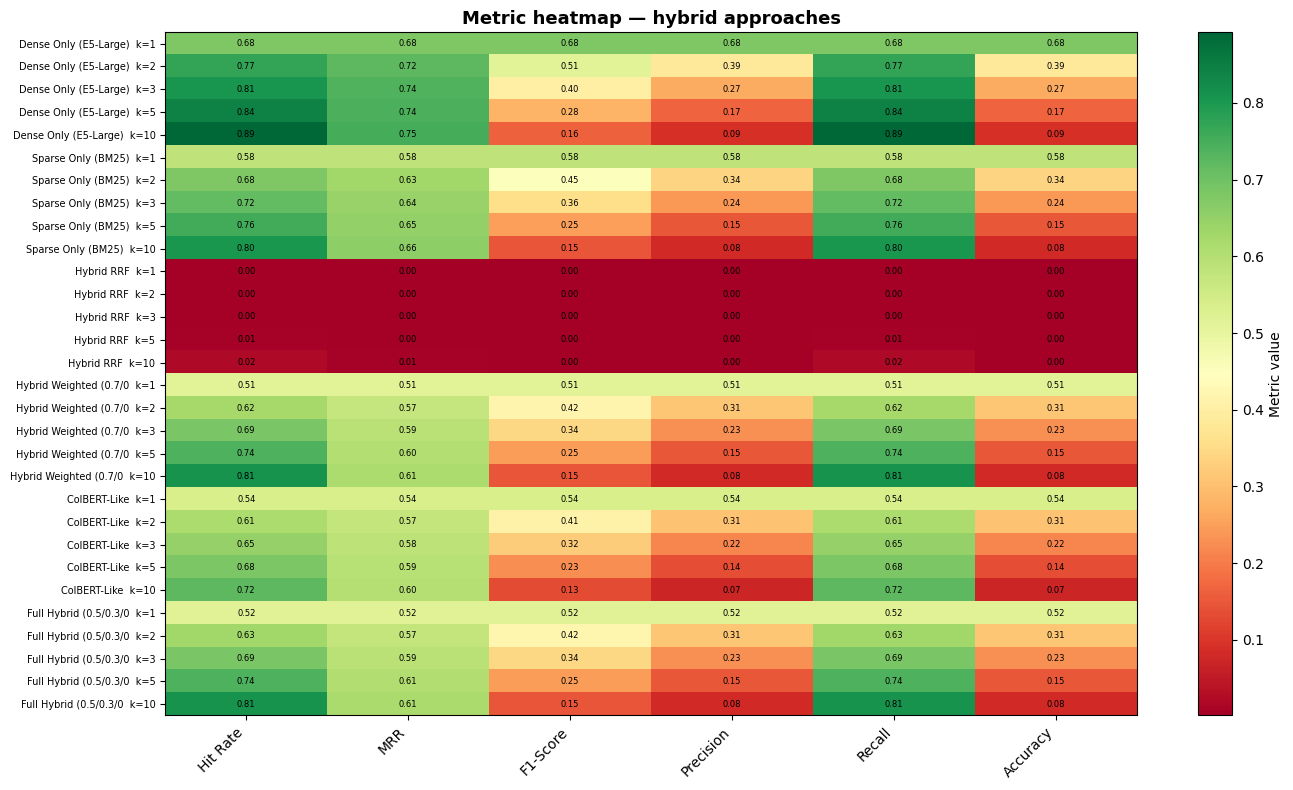

Saved: hybrid_heatmap.png
Saved: hybrid_results.json


In [10]:
from rank_bm25 import BM25Okapi

# ============================================================
# Hybrid retriever implementations
# All invoke() methods return (List[Document], scores) for
# unified handling by the shared evaluate_retriever function.
# ============================================================

class E5DenseRetriever:
    """E5-Large dense retriever."""

    def __init__(self, documents: List[Document],
                 model_name: str = "intfloat/multilingual-e5-large"):
        print("Loading E5-Large...")
        self.model = SentenceTransformer(model_name, device="cuda")
        self.documents = documents
        self.embeddings = self.model.encode(
            [d.page_content for d in documents], convert_to_numpy=True, show_progress_bar=True
        )
        print(f"Ready: {self.embeddings.shape}")

    def invoke(self, query: str, top_k: int = 10) -> Tuple[List[Document], np.ndarray]:
        q_emb = self.model.encode([query], convert_to_numpy=True)
        sims = np.dot(self.embeddings, q_emb.T).flatten()
        top_idx = sims.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx], sims[top_idx]


class BM25SparseRetriever:
    """BM25 sparse retriever."""

    def __init__(self, documents: List[Document]):
        print("Indexing BM25...")
        self.documents = documents
        self.bm25 = BM25Okapi([d.page_content.lower().split() for d in documents])
        print(f"Ready: {len(documents)} documents")

    def invoke(self, query: str, top_k: int = 10) -> Tuple[List[Document], np.ndarray]:
        scores = self.bm25.get_scores(query.lower().split())
        top_idx = scores.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx], scores[top_idx]


class HybridRRFRetriever:
    """Dense + Sparse fusion via Reciprocal Rank Fusion."""

    def __init__(self, documents: List[Document],
                 dense_model: str = "intfloat/multilingual-e5-large"):
        self.documents = documents
        print("Loading Dense (RRF)...")
        self.dense_model = SentenceTransformer(dense_model, device="cuda")
        self.dense_embs = self.dense_model.encode(
            [d.page_content for d in documents], convert_to_numpy=True
        )
        print("Indexing BM25 (RRF)...")
        self.bm25 = BM25Okapi([d.page_content.lower().split() for d in documents])

    def invoke(self, query: str, top_k: int = 10, k_param: int = 60) -> Tuple[List[Document], np.ndarray]:
        q_emb = self.dense_model.encode([query], convert_to_numpy=True)
        dense_sims = np.dot(self.dense_embs, q_emb.T).flatten()
        dense_rank = dense_sims.argsort().argsort()[::-1]
        bm25_scores = self.bm25.get_scores(query.lower().split())
        sparse_rank = bm25_scores.argsort().argsort()[::-1]
        rrf = 1 / (k_param + dense_rank + 1) + 1 / (k_param + sparse_rank + 1)
        top_idx = rrf.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx], rrf[top_idx]


class HybridWeightedRetriever:
    """Dense + Sparse fusion via linear score combination."""

    def __init__(self, documents: List[Document],
                 dense_model: str = "intfloat/multilingual-e5-large",
                 dense_weight: float = 0.7):
        self.documents = documents
        self.w_dense = dense_weight
        self.w_sparse = 1 - dense_weight
        print("Loading Dense (Weighted)...")
        self.dense_model = SentenceTransformer(dense_model, device="cuda")
        embs = self.dense_model.encode([d.page_content for d in documents], convert_to_numpy=True)
        self.scaler = StandardScaler()
        self.dense_embs = self.scaler.fit_transform(embs)
        print("Indexing BM25 (Weighted)...")
        self.bm25 = BM25Okapi([d.page_content.lower().split() for d in documents])

    def invoke(self, query: str, top_k: int = 10) -> Tuple[List[Document], np.ndarray]:
        q_emb = self.scaler.transform(self.dense_model.encode([query], convert_to_numpy=True))
        dense_sims = np.dot(self.dense_embs, q_emb.T).flatten()
        bm25_scores = self.bm25.get_scores(query.lower().split())
        bm25_norm = (bm25_scores - bm25_scores.mean()) / (bm25_scores.std() + 1e-8)
        hybrid = self.w_dense * dense_sims + self.w_sparse * bm25_norm
        top_idx = hybrid.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx], hybrid[top_idx]


class ColBERTLikeRetriever:
    """Simplified ColBERT: MaxSim token-level scoring."""

    def __init__(self, documents: List[Document],
                 model_name: str = "intfloat/multilingual-e5-large"):
        self.documents = documents
        print("Loading model for ColBERT...")
        self.model = SentenceTransformer(model_name, device="cuda")
        self.doc_token_embs: List[np.ndarray] = []
        for doc in tqdm(documents, desc="ColBERT tokenisation", ncols=70):
            tokens = doc.page_content.lower().split()[:128]
            if tokens:
                self.doc_token_embs.append(
                    self.model.encode(tokens, convert_to_numpy=True, show_progress_bar=False)
                )
            else:
                self.doc_token_embs.append(np.zeros((1, 1024)))
        print(f"ColBERT ready: {len(documents)} documents")

    def invoke(self, query: str, top_k: int = 10) -> Tuple[List[Document], np.ndarray]:
        q_tokens = query.lower().split()[:32] or ["query"]
        q_embs = self.model.encode(q_tokens, convert_to_numpy=True)
        scores = np.array([
            np.dot(d_embs, q_embs.T).max(axis=0).mean() if len(d_embs) > 0 else 0
            for d_embs in self.doc_token_embs
        ])
        top_idx = scores.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx], scores[top_idx]


class FullHybridRetriever:
    """Full hybrid: Dense + BM25 + ColBERT with configurable weights."""

    def __init__(self, documents: List[Document],
                 dense_model: str = "intfloat/multilingual-e5-large",
                 weights: Tuple[float, float, float] = (0.5, 0.3, 0.2)):
        self.documents = documents
        self.weights = weights
        print("Loading Dense (Full Hybrid)...")
        self.model = SentenceTransformer(dense_model, device="cuda")
        embs = self.model.encode([d.page_content for d in documents], convert_to_numpy=True)
        self.scaler = StandardScaler()
        self.dense_embs = self.scaler.fit_transform(embs)
        print("Indexing BM25 (Full Hybrid)...")
        self.bm25 = BM25Okapi([d.page_content.lower().split() for d in documents])
        print("Preparing ColBERT token embeddings...")
        self.doc_token_embs: List[np.ndarray] = []
        for doc in tqdm(documents, desc="ColBERT", ncols=70):
            tokens = doc.page_content.lower().split()[:128]
            if tokens:
                self.doc_token_embs.append(
                    self.model.encode(tokens, convert_to_numpy=True, show_progress_bar=False)
                )
            else:
                self.doc_token_embs.append(np.zeros((1, 1024)))
        print(f"Full Hybrid ready: weights={weights}")

    def invoke(self, query: str, top_k: int = 10) -> Tuple[List[Document], np.ndarray]:
        q_emb = self.scaler.transform(self.model.encode([query], convert_to_numpy=True))
        dense_sims = np.dot(self.dense_embs, q_emb.T).flatten()
        bm25_raw = self.bm25.get_scores(query.lower().split())
        bm25_norm = (bm25_raw - bm25_raw.mean()) / (bm25_raw.std() + 1e-8)
        q_tokens = query.lower().split()[:32] or ["query"]
        q_tok_embs = self.model.encode(q_tokens, convert_to_numpy=True)
        colbert = np.array([
            np.dot(d_embs, q_tok_embs.T).max(axis=0).mean()
            for d_embs in self.doc_token_embs
        ])
        colbert_norm = (colbert - colbert.mean()) / (colbert.std() + 1e-8)
        hybrid = (self.weights[0] * dense_sims
                  + self.weights[1] * bm25_norm
                  + self.weights[2] * colbert_norm)
        top_idx = hybrid.argsort()[-top_k:][::-1]
        return [self.documents[i] for i in top_idx], hybrid[top_idx]


# ============================================================
# Run hybrid comparison
# ============================================================

def compare_hybrid_approaches(queries_data: List[Dict], documents: List[Document]) -> Dict:
    configs = [
        ("Dense Only (E5-Large)",              lambda: E5DenseRetriever(documents)),
        ("Sparse Only (BM25)",                 lambda: BM25SparseRetriever(documents)),
        ("Hybrid RRF",                         lambda: HybridRRFRetriever(documents)),
        ("Hybrid Weighted (0.7/0.3)",          lambda: HybridWeightedRetriever(documents, dense_weight=0.7)),
        ("ColBERT-Like",                       lambda: ColBERTLikeRetriever(documents)),
        ("Full Hybrid (0.5/0.3/0.2)",          lambda: FullHybridRetriever(documents, weights=(0.5, 0.3, 0.2))),
    ]
    all_results, failed = {}, []

    print(f"\nHybrid strategy comparison: {len(configs)} approaches")
    print("=" * 100)

    for idx, (name, factory) in enumerate(configs):
        print(f"\n[{idx+1}/{len(configs)}] {name}")
        clear_gpu_memory()
        try:
            retriever = factory()
            all_results[name] = evaluate_retriever(retriever, queries_data, K_VALUES, name)
            del retriever
            clear_gpu_memory()
            r3 = all_results[name][3]
            print(f"  HR@3={r3['hit_rate']:.3f}, MRR@3={r3['mrr']:.3f}, F1@3={r3['f1']:.3f}")
        except Exception as e:
            import traceback
            print(f"  Failed: {e}")
            traceback.print_exc()
            failed.append({"name": name, "error": str(e)})
            clear_gpu_memory()

    print_results_table(all_results, K_VALUES, len(queries_data), "Hybrid Strategy Results")

    if failed:
        print("\nFailed approaches:")
        for f in failed:
            print(f"  {f['name']}: {f['error']}")

    # Improvement relative to dense-only baseline
    base_hr = all_results.get("Dense Only (E5-Large)", {}).get(3, {}).get("hit_rate", 0)
    if base_hr > 0:
        print(f"\nHit Rate@3 vs Dense Only ({base_hr:.3f}):")
        for name, res in all_results.items():
            if name != "Dense Only (E5-Large)":
                hr = res[3]["hit_rate"]
                pct = (hr - base_hr) / base_hr * 100
                marker = "+" if pct >= 0 else ""
                print(f"  {name}: {marker}{pct:.1f}%")

    # Heatmap
    if all_results:
        fig, ax = plt.subplots(figsize=(14, 8))
        heatmap_rows, y_labels = [], []
        for name in all_results:
            for k in K_VALUES:
                heatmap_rows.append([all_results[name][k][m] for m in METRIC_NAMES])
                y_labels.append(f"{name[:22]}  k={k}")
        im = ax.imshow(np.array(heatmap_rows), cmap="RdYlGn", aspect="auto")
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=7)
        ax.set_xticks(range(len(METRIC_NAMES)))
        ax.set_xticklabels([METRIC_LABELS[m].split("@")[0] for m in METRIC_NAMES],
                           rotation=45, ha="right")
        ax.set_title("Metric heatmap — hybrid approaches", fontsize=13, fontweight="bold")
        for i, row in enumerate(heatmap_rows):
            for j, val in enumerate(row):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6)
        plt.colorbar(im, ax=ax, label="Metric value")
        plt.tight_layout()
        plt.savefig("hybrid_heatmap.png", dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved: hybrid_heatmap.png")

    with open("hybrid_results.json", "w", encoding="utf-8") as f:
        json.dump({"results": all_results, "failed": failed}, f, ensure_ascii=False, indent=2, default=str)
    print("Saved: hybrid_results.json")
    return all_results


queries = load_queries(GROUND_TRUTH_PATH)
documents = create_documents(queries)
clear_gpu_memory()
hybrid_results = compare_hybrid_approaches(queries, documents)
clear_gpu_memory()


## 5. Reranker Uplift Analysis

Measures the metric improvement (uplift) of adding a cross-encoder reranker over the dense-only baseline.
Three rerankers evaluated:
- MiniLM-L6 (cross-encoder/ms-marco-MiniLM-L-6-v2)
- BGE-Reranker-Base (BAAI/bge-reranker-base)
- BGE-Reranker-Large (BAAI/bge-reranker-large)

Loaded 1276 queries from ground_truth_qwery.json
Created 425 unique documents

Reranker uplift analysis
  Queries: 50, k_values: [1, 2, 3, 5, 10]


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Baseline evaluation...



Evaluating MiniLM...


...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]


Reranker Absolute Metrics

Top-1:
+------------------+------+-------+------+--------+-------+-------+---------+
| Model/Approach   |   HR |   MRR |   F1 |   Prec |   Rec |   Acc | Found   |
+==================+======+=======+======+========+=======+=======+=========+
| Baseline         | 0.64 |  0.64 | 0.64 |   0.64 |  0.64 |  0.64 | 32/50   |
+------------------+------+-------+------+--------+-------+-------+---------+
| MiniLM           | 0.86 |  0.86 | 0.86 |   0.86 |  0.86 |  0.86 | 43/50   |
+------------------+------+-------+------+--------+-------+-------+---------+
| BGE-Base         | 0.92 |  0.92 | 0.92 |   0.92 |  0.92 |  0.92 | 46/50   |
+------------------+------+-------+------+--------+-------+-------+---------+
| BGE-Large        | 0.92 |  0.92 | 0.92 |   0.92 |  0.92 |  0.92 | 46/50   |
+------------------+------+-------+------+--------+-------+-------+---------+

Top-2:
+------------------+------+-------+--------+--------+-------+-------+---------+
| Model/Approach   

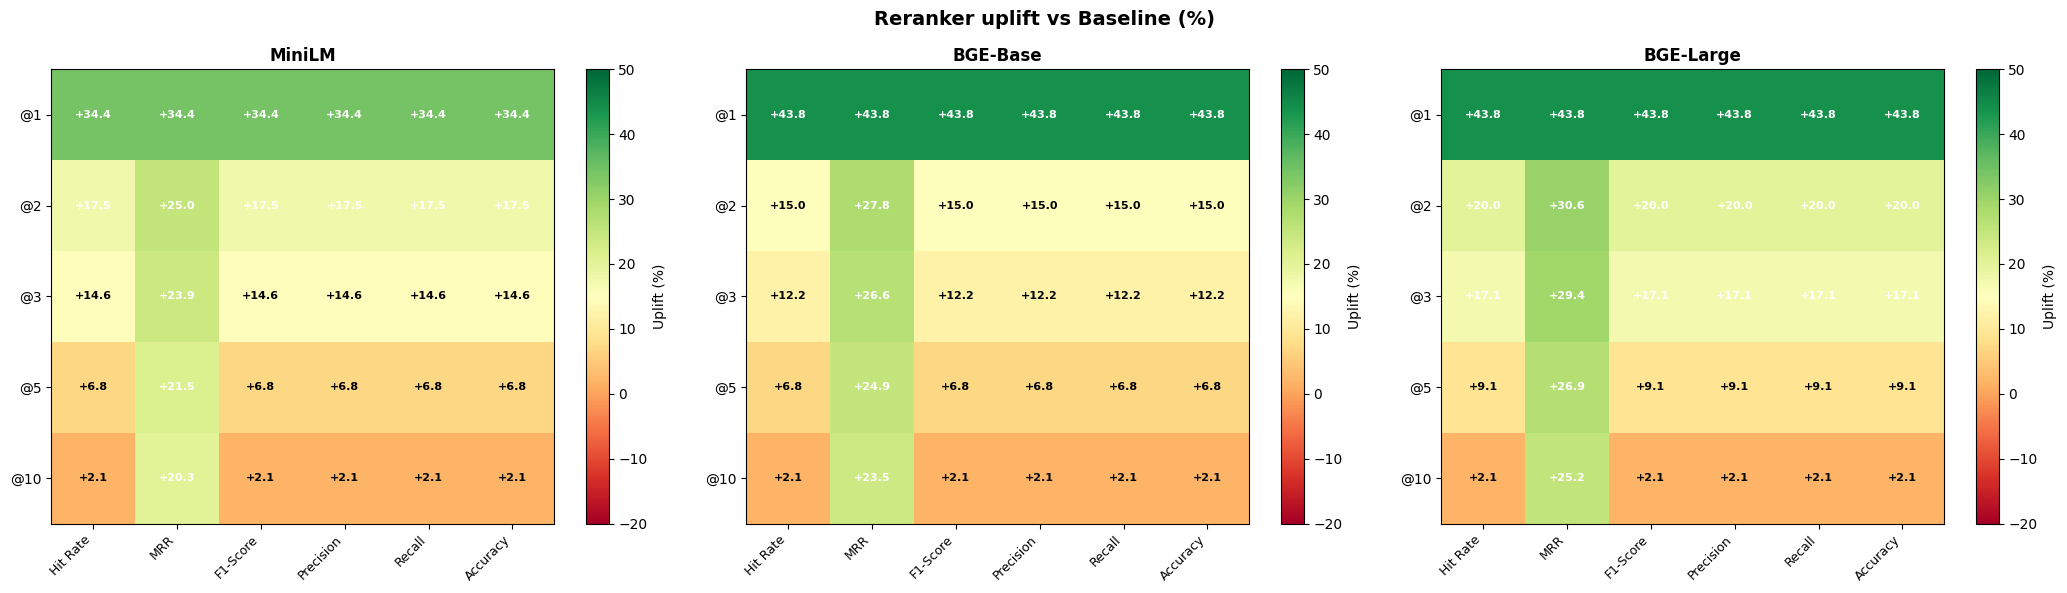

Saved: uplift_heatmap.png

Best reranker overall: BGE-Large (avg uplift +20.53%)
Saved: uplift_results.json


In [11]:
# ============================================================
# Retrievers for reranker analysis
# Both classes take dense_model as a parameter to invoke()
# so a single model instance can be shared across retrievers.
# ============================================================

class DenseBaselineRetriever:
    def __init__(self, documents: List[Document], embeddings: np.ndarray):
        self.documents = documents
        self.embeddings = embeddings

    def invoke(self, query: str, top_k: int = 10, dense_model=None) -> List[Document]:
        q_emb = dense_model.encode([query], convert_to_numpy=True)
        sims = np.dot(self.embeddings, q_emb.T).flatten()
        return [self.documents[i] for i in sims.argsort()[-top_k:][::-1]]


class DenseWithRerankerRetriever:
    def __init__(self, documents: List[Document], embeddings: np.ndarray,
                 reranker_model: str, retrieve_k: int = 20):
        self.documents = documents
        self.embeddings = embeddings
        self.retrieve_k = retrieve_k
        self.reranker = CrossEncoder(reranker_model, device="cuda")

    def invoke(self, query: str, top_k: int = 10, dense_model=None) -> List[Document]:
        q_emb = dense_model.encode([query], convert_to_numpy=True)
        sims = np.dot(self.embeddings, q_emb.T).flatten()
        candidate_idx = sims.argsort()[-self.retrieve_k:][::-1]
        candidates = [self.documents[i] for i in candidate_idx]
        scores = self.reranker.predict([[query, d.page_content] for d in candidates])
        final_idx = np.argsort(scores)[::-1][:top_k]
        return [candidates[i] for i in final_idx]


# ============================================================
# Uplift analysis
# ============================================================

def analyze_reranker_uplift(queries_data: List[Dict], documents: List[Document]) -> Dict:
    reranker_configs = [
        ("cross-encoder/ms-marco-MiniLM-L-6-v2", "MiniLM"),
        ("BAAI/bge-reranker-base",               "BGE-Base"),
        ("BAAI/bge-reranker-large",              "BGE-Large"),
    ]
    test_queries = queries_data[:50] if len(queries_data) > 50 else queries_data

    print("\nReranker uplift analysis")
    print(f"  Queries: {len(test_queries)}, k_values: {K_VALUES}")
    print("=" * 100)

    clear_gpu_memory()
    dense_model = SentenceTransformer("intfloat/multilingual-e5-large", device="cuda")
    all_embs = dense_model.encode([d.page_content for d in documents], convert_to_numpy=True)

    # Baseline
    print("\nBaseline evaluation...")
    baseline = DenseBaselineRetriever(documents, all_embs)
    baseline_results = evaluate_retriever(baseline, test_queries, K_VALUES, "Baseline", dense_model=dense_model)
    del baseline
    clear_gpu_memory()

    # Rerankers
    all_results = {"Baseline": baseline_results}
    for model_path, short_name in reranker_configs:
        print(f"\nEvaluating {short_name}...")
        retriever = DenseWithRerankerRetriever(documents, all_embs, model_path, retrieve_k=20)
        all_results[short_name] = evaluate_retriever(
            retriever, test_queries, K_VALUES, short_name, dense_model=dense_model
        )
        del retriever
        clear_gpu_memory()

    del dense_model
    clear_gpu_memory()

    # Uplift calculation
    reranker_names = [s for _, s in reranker_configs]
    uplift = {}
    for name in reranker_names:
        uplift[name] = {}
        for k in K_VALUES:
            uplift[name][k] = {}
            for m in METRIC_NAMES:
                base_val = baseline_results[k][m]
                curr_val = all_results[name][k][m]
                uplift[name][k][m] = round(
                    ((curr_val - base_val) / base_val * 100) if base_val > 0 else 0, 2
                )

    print_results_table(all_results, K_VALUES, len(test_queries), "Reranker Absolute Metrics")

    # Uplift table at k=3
    print("\nUplift vs Baseline at k=3:")
    rows = []
    for name in reranker_names:
        row = [name] + [f"{uplift[name][3][m]:+.2f}%" for m in METRIC_NAMES]
        rows.append(row)
    print(tabulate(rows, headers=["Reranker"] + [METRIC_LABELS[m] for m in METRIC_NAMES], tablefmt="grid"))

    # Heatmap per reranker
    fig, axes = plt.subplots(1, len(reranker_names), figsize=(7 * len(reranker_names), 6))
    if len(reranker_names) == 1:
        axes = [axes]
    for ax, name in zip(axes, reranker_names):
        data = np.array([[uplift[name][k][m] for m in METRIC_NAMES] for k in K_VALUES])
        im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=-20, vmax=50)
        ax.set_xticks(range(len(METRIC_NAMES)))
        ax.set_xticklabels([METRIC_LABELS[m] for m in METRIC_NAMES], rotation=45, ha="right", fontsize=9)
        ax.set_yticks(range(len(K_VALUES)))
        ax.set_yticklabels([f"@{k}" for k in K_VALUES])
        ax.set_title(name, fontsize=12, fontweight="bold")
        for i, k in enumerate(K_VALUES):
            for j, m in enumerate(METRIC_NAMES):
                ax.text(j, i, f"{uplift[name][k][m]:+.1f}", ha="center", va="center",
                        fontsize=8, fontweight="bold",
                        color="white" if abs(uplift[name][k][m]) > 15 else "black")
        plt.colorbar(im, ax=ax, label="Uplift (%)")
    fig.suptitle("Reranker uplift vs Baseline (%)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("uplift_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: uplift_heatmap.png")

    # Overall best
    overall = {
        name: np.mean([uplift[name][k][m] for k in K_VALUES for m in METRIC_NAMES])
        for name in reranker_names
    }
    best = max(overall, key=overall.get)
    print(f"\nBest reranker overall: {best} (avg uplift {overall[best]:+.2f}%)")

    with open("uplift_results.json", "w", encoding="utf-8") as f:
        json.dump({
            "baseline": baseline_results,
            "rerankers": {n: all_results[n] for n in reranker_names},
            "uplift": uplift,
            "best": best,
            "best_avg_uplift": overall[best],
        }, f, ensure_ascii=False, indent=2)
    print("Saved: uplift_results.json")
    return uplift


queries = load_queries(GROUND_TRUTH_PATH)
documents = create_documents(queries)
uplift_data = analyze_reranker_uplift(queries, documents)


## 6. Final Validation

End-to-end evaluation of the selected architecture:
**E5-Large (retrieve k=20) → BGE-Reranker-Large (return top k)**

Includes latency statistics (avg, P50, P95, P99).

Loaded 1276 queries from ground_truth_qwery.json
Created 425 unique documents

Final Validation: E5-Large + BGE-Reranker-Large
  Documents: 425, Queries: 1276, k=[1, 2, 3, 5, 10]
Loading E5-Large...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading BGE-Reranker-Large...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

Encoding documents...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

System ready (retrieve_k=20)


Final evaluation: 100%|███████████| 1276/1276 [41:52<00:00,  1.97s/it]



Metrics by k:
+-----+------------+--------+------------+-------------+----------+------------+-----------+
| k   |   Hit Rate |    MRR |   F1-Score |   Precision |   Recall |   Accuracy | Found     |
+=====+============+========+============+=============+==========+============+===========+
| @1  |     0.8237 | 0.8237 |     0.8237 |      0.8237 |   0.8237 |     0.8237 | 1051/1276 |
+-----+------------+--------+------------+-------------+----------+------------+-----------+
| @2  |     0.8856 | 0.8546 |     0.5904 |      0.4428 |   0.8856 |     0.4428 | 1130/1276 |
+-----+------------+--------+------------+-------------+----------+------------+-----------+
| @3  |     0.8997 | 0.8593 |     0.4498 |      0.2999 |   0.8997 |     0.2999 | 1148/1276 |
+-----+------------+--------+------------+-------------+----------+------------+-----------+
| @5  |     0.9177 | 0.8636 |     0.3059 |      0.1835 |   0.9177 |     0.1835 | 1171/1276 |
+-----+------------+--------+------------+-------------

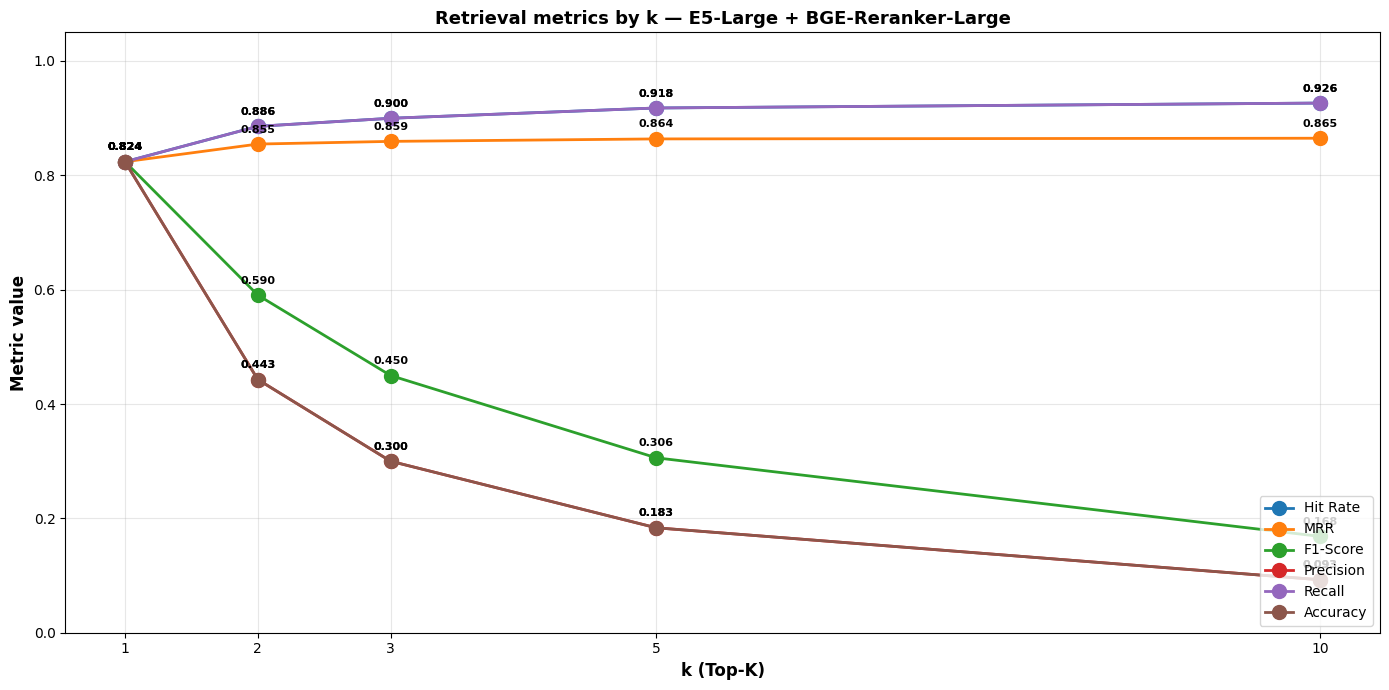

Saved: final_metrics_by_k.png


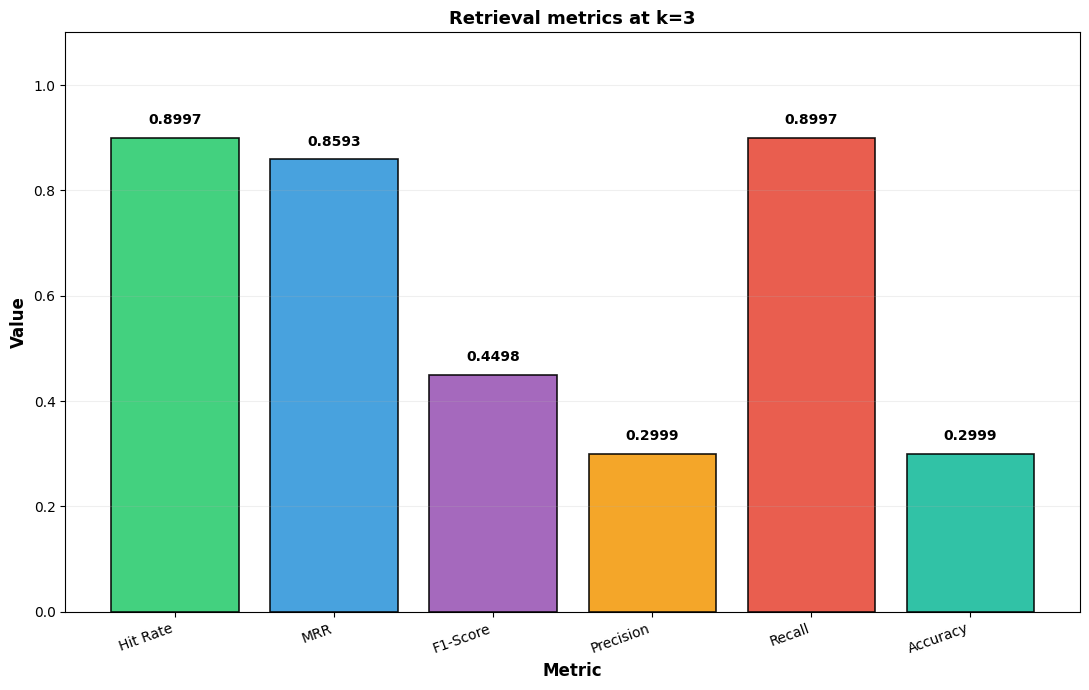

Saved: final_metrics_k3.png
Saved: final_metrics_E5_BGE_Large.json

Key results at k=3:
  Hit Rate:  0.8997
  MRR:       0.8593
  F1-Score:  0.4498
  Precision: 0.2999
  Recall:    0.8997
  Accuracy:  0.2999
  Found:     1148/1276
  Avg latency: 1967.24 ms


In [12]:
# ============================================================
# Final system: E5-Large + BGE-Reranker-Large
# ============================================================

class FinalRerankerSystem:
    """Production configuration: E5-Large dense retrieval + BGE-Reranker-Large."""

    def __init__(self, documents: List[Document], retrieve_k: int = 20):
        print("Loading E5-Large...")
        self.dense_model = SentenceTransformer("intfloat/multilingual-e5-large", device="cuda")
        print("Loading BGE-Reranker-Large...")
        self.reranker = CrossEncoder("BAAI/bge-reranker-large", device="cuda")
        self.documents = documents
        self.retrieve_k = retrieve_k
        print("Encoding documents...")
        self.embeddings = self.dense_model.encode(
            [d.page_content for d in documents],
            convert_to_numpy=True,
            show_progress_bar=True,
        )
        print(f"System ready (retrieve_k={retrieve_k})")

    def search(self, query: str, top_k: int = 10) -> List[Document]:
        q_emb = self.dense_model.encode([query], convert_to_numpy=True)
        sims = np.dot(self.embeddings, q_emb.T).flatten()
        candidate_idx = sims.argsort()[-self.retrieve_k:][::-1]
        candidates = [self.documents[i] for i in candidate_idx]
        scores = self.reranker.predict([[query, d.page_content] for d in candidates])
        final_idx = np.argsort(scores)[::-1][:top_k]
        return [candidates[i] for i in final_idx]


def evaluate_final_system(
    retriever: FinalRerankerSystem,
    queries: List[Dict],
    k_values: List[int],
) -> Dict:
    """Evaluate the final system with per-query latency tracking."""
    bucket = {k: {m: [] for m in METRIC_NAMES} for k in k_values}
    timings = []

    for item in tqdm(queries, desc="Final evaluation", ncols=70):
        gt_id = _ground_truth_id(item)
        t0 = time.time()
        retrieved = retriever.search(item["query"], top_k=max(k_values))
        timings.append((time.time() - t0) * 1000)
        for k in k_values:
            for m, v in calculate_metrics(retrieved, gt_id, k).items():
                bucket[k][m].append(v)

    result = {}
    for k in k_values:
        result[k] = {m: round(float(np.mean(bucket[k][m])), 4) for m in METRIC_NAMES}
        result[k]["found_count"] = int(sum(bucket[k]["hit_rate"]))
        result[k]["total"] = len(queries)
    result["timing"] = {
        "avg_ms":  round(float(np.mean(timings)), 2),
        "p50_ms":  round(float(np.percentile(timings, 50)), 2),
        "p95_ms":  round(float(np.percentile(timings, 95)), 2),
        "p99_ms":  round(float(np.percentile(timings, 99)), 2),
    }
    return result


def final_validation(queries: List[Dict], documents: List[Document]) -> Dict:
    print("\n" + "=" * 100)
    print("Final Validation: E5-Large + BGE-Reranker-Large")
    print(f"  Documents: {len(documents)}, Queries: {len(queries)}, k={K_VALUES}")
    print("=" * 100)

    clear_gpu_memory()
    system = FinalRerankerSystem(documents, retrieve_k=20)
    results = evaluate_final_system(system, queries, K_VALUES)
    clear_gpu_memory()

    # Metrics table
    rows = []
    for k in K_VALUES:
        row = [f"@{k}"] + [f"{results[k][m]:.4f}" for m in METRIC_NAMES]
        row.append(f"{results[k]['found_count']}/{results[k]['total']}")
        rows.append(row)
    print("\nMetrics by k:")
    print(tabulate(rows, headers=["k"] + [METRIC_LABELS[m] for m in METRIC_NAMES] + ["Found"],
                   tablefmt="grid"))

    # Latency table
    t = results["timing"]
    print("\nLatency statistics:")
    print(tabulate([
        ["Average",  f"{t['avg_ms']:.2f} ms"],
        ["Median",   f"{t['p50_ms']:.2f} ms"],
        ["P95",      f"{t['p95_ms']:.2f} ms"],
        ["P99",      f"{t['p99_ms']:.2f} ms"],
    ], headers=["Metric", "Value"], tablefmt="grid"))

    # Visualisation 1: all metrics by k
    fig1, ax1 = plt.subplots(figsize=(14, 7))
    for metric in METRIC_NAMES:
        values = [results[k][metric] for k in K_VALUES]
        ax1.plot(K_VALUES, values, marker="o", linewidth=2, markersize=10, label=METRIC_LABELS[metric])
        for i, v in enumerate(values):
            ax1.text(K_VALUES[i], v + 0.02, f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")
    ax1.set_xlabel("k (Top-K)", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Metric value", fontsize=12, fontweight="bold")
    ax1.set_title("Retrieval metrics by k — E5-Large + BGE-Reranker-Large", fontsize=13, fontweight="bold")
    ax1.set_xticks(K_VALUES)
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10, loc="lower right")
    plt.tight_layout()
    plt.savefig("final_metrics_by_k.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: final_metrics_by_k.png")

    # Visualisation 2: bar chart at k=3
    fig2, ax2 = plt.subplots(figsize=(11, 7))
    x = np.arange(len(METRIC_NAMES))
    values_k3 = [results[3][m] for m in METRIC_NAMES]
    colors = ["#2ECC71", "#3498DB", "#9B59B6", "#F39C12", "#E74C3C", "#1ABC9C"]
    bars = ax2.bar(x, values_k3, color=colors, edgecolor="black", linewidth=1.2, alpha=0.9)
    for bar, val in zip(bars, values_k3):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax2.set_xlabel("Metric", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Value", fontsize=12, fontweight="bold")
    ax2.set_title("Retrieval metrics at k=3", fontsize=13, fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels([METRIC_LABELS[m] for m in METRIC_NAMES], rotation=20, ha="right")
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, alpha=0.2, axis="y")
    plt.tight_layout()
    plt.savefig("final_metrics_k3.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: final_metrics_k3.png")

    # Save results
    output = {
        "configuration": {
            "dense_model": "intfloat/multilingual-e5-large",
            "reranker_model": "BAAI/bge-reranker-large",
            "retrieve_k": 20,
            "documents_count": len(documents),
            "queries_count": len(queries),
        },
        "metrics_by_k": {str(k): {m: results[k][m] for m in METRIC_NAMES} for k in K_VALUES},
        "timing": results["timing"],
        "key_metrics_k3": {m: results[3][m] for m in METRIC_NAMES},
    }
    with open("final_metrics_E5_BGE_Large.json", "w", encoding="utf-8") as f:
        json.dump(output, f, ensure_ascii=False, indent=2)
    print("Saved: final_metrics_E5_BGE_Large.json")

    r3 = results[3]
    print(f"\nKey results at k=3:")
    print(f"  Hit Rate:  {r3['hit_rate']:.4f}")
    print(f"  MRR:       {r3['mrr']:.4f}")
    print(f"  F1-Score:  {r3['f1']:.4f}")
    print(f"  Precision: {r3['precision']:.4f}")
    print(f"  Recall:    {r3['recall']:.4f}")
    print(f"  Accuracy:  {r3['accuracy']:.4f}")
    print(f"  Found:     {r3['found_count']}/{r3['total']}")
    print(f"  Avg latency: {results['timing']['avg_ms']:.2f} ms")
    return results


queries = load_queries(GROUND_TRUTH_PATH)
documents = create_documents(queries)
final_results = final_validation(queries, documents)
